# DiabeticLens — Model Evaluation and Tuning

This notebook evaluates the machine learning models trained in Notebook 03.

The evaluation focuses on:
- Confusion Matrix
- Classification Report
- ROC-AUC
- Precision-Recall Curve
- Cross-Validation
- Hyperparameter Tuning
- Threshold Analysis
- Final Model Selection

The goal is to select a suitable diabetes prediction model while considering
the class imbalance in the dataset.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)

In [2]:
df = pd.read_csv("../data/diabetes.csv")

print("Original dataset shape:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Original dataset shape: (100000, 9)
After removing duplicates: (96146, 9)


In [3]:
df = pd.read_csv("../data/diabetes.csv")

print("Original dataset shape:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Original dataset shape: (100000, 9)
After removing duplicates: (96146, 9)


In [4]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (96146, 8)
Target shape: (96146,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (76916, 8)
X_test: (19230, 8)
y_train: (76916,)
y_test: (19230,)


In [6]:
preprocessor = joblib.load("../models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (76916, 15)
Processed testing data: (19230, 15)


In [7]:
logistic_model = joblib.load("../models/logistic_regression.pkl")
decision_tree = joblib.load("../models/decision_tree.pkl")
random_forest = joblib.load("../models/random_forest.pkl")
knn = joblib.load("../models/knn.pkl")
gradient_boosting = joblib.load("../models/gradient_boosting.pkl")

print("All saved models loaded successfully.")

All saved models loaded successfully.


In [8]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "KNN": knn,
    "Gradient Boosting": gradient_boosting
}

predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_processed)

print("Predictions generated successfully.")

Predictions generated successfully.


In [9]:
for name, model in models.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    print(
        classification_report(
            y_test,
            predictions[name],
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0     0.9659    0.9908    0.9782     17534
           1     0.8699    0.6386    0.7365      1696

    accuracy                         0.9597     19230
   macro avg     0.9179    0.8147    0.8573     19230
weighted avg     0.9574    0.9597    0.9569     19230

Decision Tree
              precision    recall  f1-score   support

           0     0.9748    0.9685    0.9716     17534
           1     0.6945    0.7412    0.7171      1696

    accuracy                         0.9484     19230
   macro avg     0.8346    0.8548    0.8443     19230
weighted avg     0.9501    0.9484    0.9492     19230

Random Forest
              precision    recall  f1-score   support

           0     0.9707    0.9965    0.9834     17534
           1     0.9496    0.6887    0.7984      1696

    accuracy                         0.9693     19230
   macro avg     0.9601    0.8426    0.8909     19230
weighted avg     0.9688   

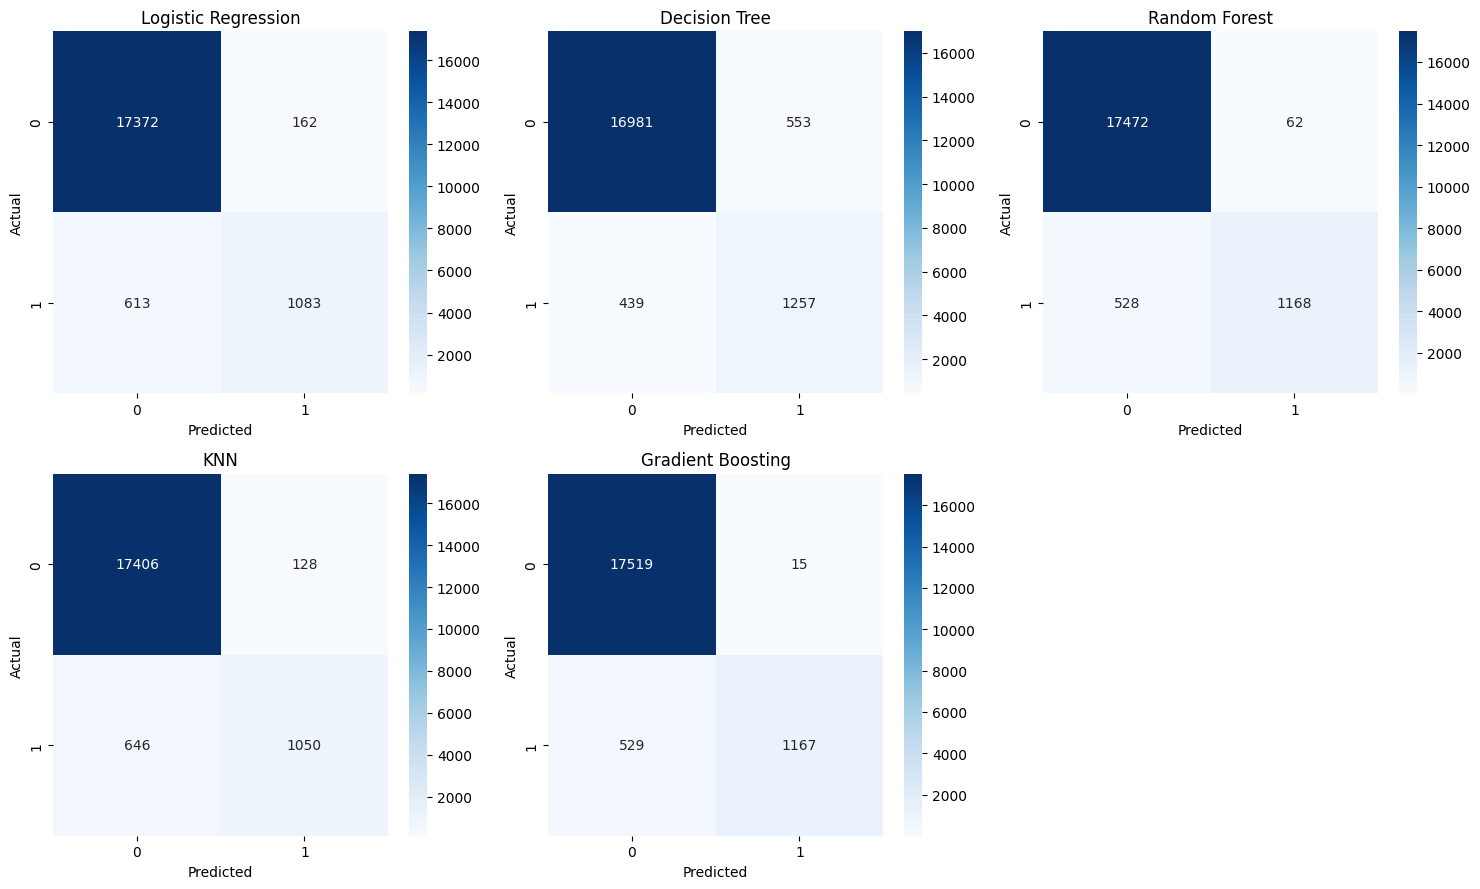

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

for i, (name, pred) in enumerate(predictions.items()):
    
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i]
    )
    
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

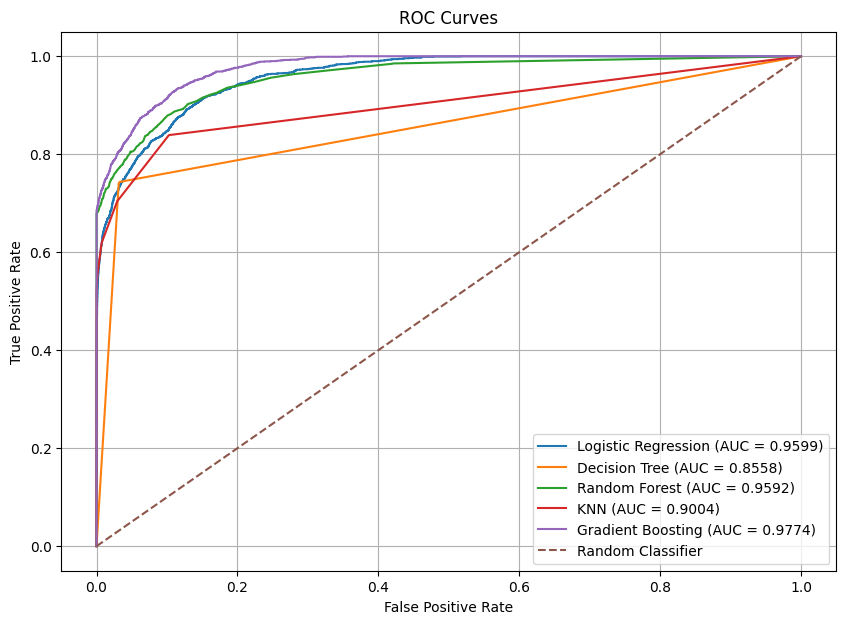

In [11]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

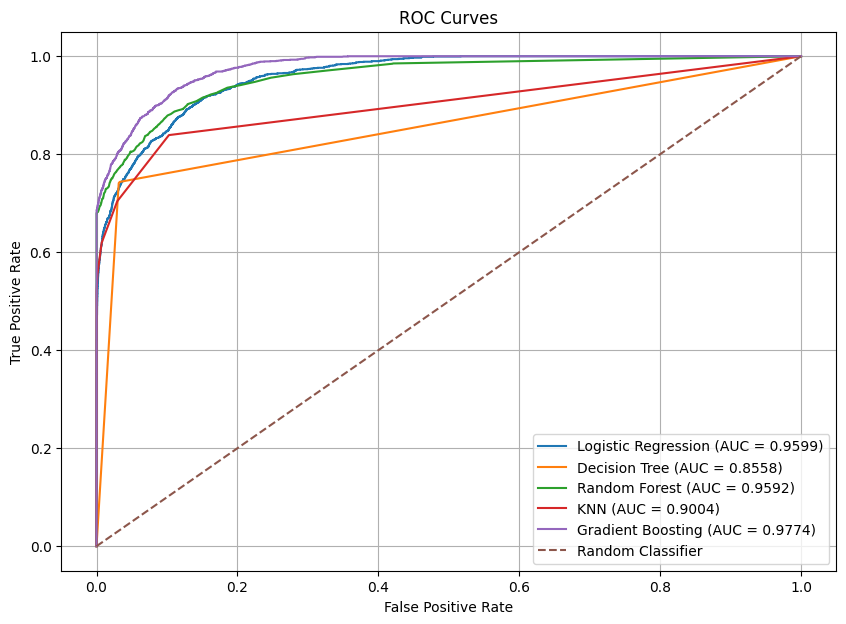

In [12]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

In [13]:
evaluation_results = []

for name, model in models.items():
    
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9597,0.8699,0.6386,0.7365,0.9599,0.8174
1,Decision Tree,0.9484,0.6945,0.7412,0.7171,0.8558,0.5390
2,Random Forest,0.9693,0.9496,0.6887,0.7984,0.9592,0.8521
3,KNN,0.9598,0.8913,0.6191,0.7307,0.9004,0.7432
4,Gradient Boosting,0.9717,0.9873,0.6881,0.8110,0.9774,0.8841


In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [15]:
gb_cv_scores = cross_val_score(
    gradient_boosting,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Gradient Boosting F1 scores:")
print(gb_cv_scores)

print("\nMean F1:", gb_cv_scores.mean())
print("Standard Deviation:", gb_cv_scores.std())

Gradient Boosting F1 scores:
[0.7890797  0.80453752 0.80382775 0.80799305 0.81188119]

Mean F1: 0.8034638422449165
Standard Deviation: 0.007740209032306904


In [16]:
rf_cv_scores = cross_val_score(
    random_forest,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Random Forest F1 scores:")
print(rf_cv_scores)

print("\nMean F1:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest F1 scores:
[0.78305964 0.79381443 0.78728814 0.79693487 0.794193  ]

Mean F1: 0.7910580137827206
Standard Deviation: 0.005101948118578072


In [17]:
param_dist = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [18]:
gb_tuning = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

gb_tuning.fit(
    X_train_processed,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter tuning completed.


In [19]:
print("Best Parameters:")
print(gb_tuning.best_params_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.1}


In [20]:
print("Best Cross-Validation F1 Score:")
print(gb_tuning.best_score_)

Best Cross-Validation F1 Score:
0.8043494978853446


In [21]:
tuned_gb = gb_tuning.best_estimator_

tuned_gb_pred = tuned_gb.predict(
    X_test_processed
)

tuned_gb_prob = tuned_gb.predict_proba(
    X_test_processed
)[:, 1]

print("Tuned Gradient Boosting evaluated successfully.")

Tuned Gradient Boosting evaluated successfully.


In [22]:
tuned_results = {
    "Accuracy": accuracy_score(y_test, tuned_gb_pred),
    "Precision": precision_score(y_test, tuned_gb_pred),
    "Recall": recall_score(y_test, tuned_gb_pred),
    "F1": f1_score(y_test, tuned_gb_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_gb_prob),
    "PR-AUC": average_precision_score(y_test, tuned_gb_prob)
}

pd.DataFrame(
    [tuned_results],
    index=["Tuned Gradient Boosting"]
).round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Tuned Gradient Boosting,0.9718,0.9882,0.6887,0.8117,0.9775,0.8842


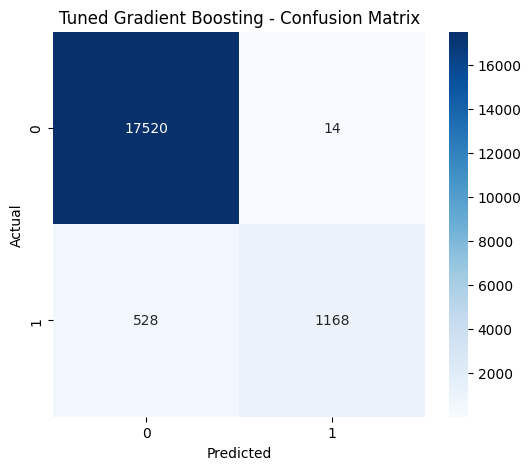

In [23]:
cm = confusion_matrix(
    y_test,
    tuned_gb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
print(
    classification_report(
        y_test,
        tuned_gb_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9707    0.9992    0.9848     17534
           1     0.9882    0.6887    0.8117      1696

    accuracy                         0.9718     19230
   macro avg     0.9795    0.8439    0.8982     19230
weighted avg     0.9723    0.9718    0.9695     19230



In [25]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (
        tuned_gb_prob >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.10,0.4958,0.9039,0.6404
1,0.15,0.6176,0.8467,0.7143
2,0.20,0.7105,0.8031,0.7539
3,0.25,0.7984,0.7659,0.7818
4,0.30,0.8630,0.7429,0.7985
5,0.35,0.9135,0.7223,0.8067
6,0.40,0.9435,0.7093,0.8098
7,0.45,0.9776,0.6958,0.8130
8,0.50,0.9882,0.6887,0.8117
9,0.55,0.9957,0.6846,0.8113


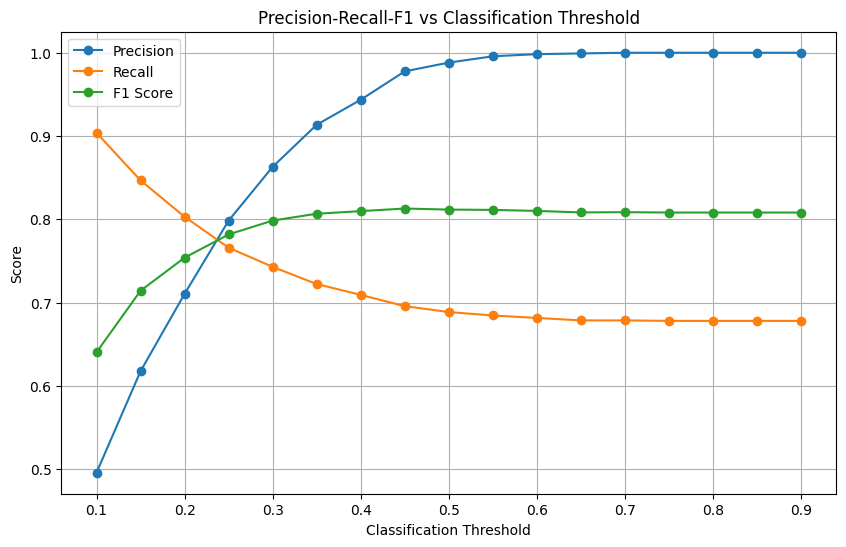

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Classification Threshold")

plt.legend()
plt.grid()

plt.show()

In [27]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
Threshold    0.450000
Precision    0.977630
Recall       0.695755
F1           0.812952
Name: 7, dtype: float64


In [28]:
original_gb_metrics = {
    "Model": "Original Gradient Boosting",
    "Accuracy": accuracy_score(
        y_test,
        predictions["Gradient Boosting"]
    ),
    "Precision": precision_score(
        y_test,
        predictions["Gradient Boosting"]
    ),
    "Recall": recall_score(
        y_test,
        predictions["Gradient Boosting"]
    ),
    "F1": f1_score(
        y_test,
        predictions["Gradient Boosting"]
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        gradient_boosting.predict_proba(
            X_test_processed
        )[:, 1]
    )
}

tuned_gb_metrics = {
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(
        y_test,
        tuned_gb_pred
    ),
    "Precision": precision_score(
        y_test,
        tuned_gb_pred
    ),
    "Recall": recall_score(
        y_test,
        tuned_gb_pred
    ),
    "F1": f1_score(
        y_test,
        tuned_gb_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        tuned_gb_prob
    )
}

gb_comparison = pd.DataFrame([
    original_gb_metrics,
    tuned_gb_metrics
])

gb_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Original Gradient Boosting,0.9717,0.9873,0.6881,0.8110,0.9774
1,Tuned Gradient Boosting,0.9718,0.9882,0.6887,0.8117,0.9775


In [29]:
final_model = tuned_gb

print("Final model:")
print(final_model)

Final model:
GradientBoostingClassifier(max_depth=2, min_samples_leaf=2, min_samples_split=5,
                           n_estimators=150, random_state=42)


In [30]:
joblib.dump(
    final_model,
    "../models/final_diabetes_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [31]:
best_threshold = float(
    best_threshold_row["Threshold"]
)

joblib.dump(
    best_threshold,
    "../models/decision_threshold.pkl"
)

print(
    "Decision threshold saved:",
    best_threshold
)

Decision threshold saved: 0.45000000000000007


In [32]:
evaluation_df.to_csv(
    "../models/evaluation_results.csv",
    index=False
)

threshold_df.to_csv(
    "../models/threshold_analysis.csv",
    index=False
)

gb_comparison.to_csv(
    "../models/gradient_boosting_comparison.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [33]:
print("=" * 70)
print("DIABETICLENS - FINAL MODEL SUMMARY")
print("=" * 70)

print("\nFinal Model:")
print("Tuned Gradient Boosting")

print("\nBest Threshold Based on F1:")
print(round(best_threshold, 2))

print("\nFinal Test Metrics:")

print(
    f"Accuracy  : {accuracy_score(y_test, tuned_gb_pred):.4f}"
)

print(
    f"Precision : {precision_score(y_test, tuned_gb_pred):.4f}"
)

print(
    f"Recall    : {recall_score(y_test, tuned_gb_pred):.4f}"
)

print(
    f"F1 Score  : {f1_score(y_test, tuned_gb_pred):.4f}"
)

print(
    f"ROC-AUC   : {roc_auc_score(y_test, tuned_gb_prob):.4f}"
)

print(
    f"PR-AUC    : {average_precision_score(y_test, tuned_gb_prob):.4f}"
)

print("\nModel saved successfully.")

DIABETICLENS - FINAL MODEL SUMMARY

Final Model:
Tuned Gradient Boosting

Best Threshold Based on F1:
0.45

Final Test Metrics:
Accuracy  : 0.9718
Precision : 0.9882
Recall    : 0.6887
F1 Score  : 0.8117
ROC-AUC   : 0.9775
PR-AUC    : 0.8842

Model saved successfully.
